# 实验三 线性分类器 (以`支持向量机`为主进行对比)

姓名：王智颍

学号：3238507069

班级：3班

日期：2025.12.19


支持向量机（SVM）是线性方法的扩展，它们试图用超平面来分隔类别。

这些扩展分为三个步骤：

当类别线性可分时，最大化两个类别之间的间隔。
当类别不是线性可分时，最大化间隔但允许一些样本在间隔内。这就是软间隔。
“核技巧”将分隔扩展到非线性边界。
核技巧的性能提升使得SVM成为了2000年代最好的分类方法，直到深度神经网络的出现。

**学习目标:**
1. 理解并实现上述提到的SVM概念
2. 将SVM应用于非线性问题（XOR）并使用非线性核（高斯径向基函数RBF）

In [172]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as pltcolors
from sklearn import linear_model, svm, discriminant_analysis, metrics
import seaborn as sns

## 1、数据模型


让我们使用一个简单的模型，包含两个相隔很远的高斯分布，以便它们可以被分隔开。

In [173]:
colors = ['blue','red']
cmap = pltcolors.ListedColormap(colors)
nFeatures = 2
N = 100

def generateBatchBipolar(n, mu=0.5, sigma=0.2):
    """ Two gaussian clouds on each side of the origin """
    X = np.random.normal(mu, sigma, (n, 2))
    yB = np.random.uniform(0, 1, n) > 0.5
    # y is in {-1, 1}
    y = 2. * yB - 1
    X *= y[:, np.newaxis]
    X -= X.mean(axis=0)
    return X, y

## 2、辅助函数

In [174]:
def plotLine(ax, xRange, w, x0, label, color='grey', linestyle='-', alpha=1.):
    """ 给定法向量（权重）和截距点，绘制一条（分隔的）直线 """
    if type(x0) == int or type(x0) == float or type(x0) == np.float64:
        x0 = [0, -x0 / w[1]]
    yy = -(w[0] / w[1]) * (xRange - x0[0]) + x0[1]
    ax.plot(xRange, yy, color=color, label=label, linestyle=linestyle)

def plotSvm(X, y, support=None, w=None, intercept=0., label='Data', separatorLabel='Separator', 
            ax=None, bound=[[-1., 1.], [-1., 1.]]):
    """ 绘制SVM的分隔线和间隔 """
    if ax is None:
        fig, ax = plt.subplots(1)
    
    im = ax.scatter(X[:,0], X[:,1], c=y, cmap=cmap, alpha=0.5, label=label)                 # 绘制散点图
    if support is not None:                                                                 # 绘制支持向量
        ax.scatter(support[:,0], support[:,1], label='Support', s=80, facecolors='none', 
                   edgecolors='y', color='y')
        print("Number of support vectors = %d" % (len(support)))

    if w is not None:
        xx = np.array(bound[0])
        plotLine(ax, xx, w, intercept, separatorLabel)
        
        # Plot margin
        if support is not None:
            margin = 1 / np.sqrt(np.dot(w, w))
            plotLine(ax, xx, w, 1+intercept, 'Margin -', linestyle='-.', alpha=0.8)
            plotLine(ax, xx, w, -1+intercept, 'Margin +', linestyle='-.', alpha=0.8)
            ax.set_title('Margin = %.3f' % (margin))
    
    ax.legend(loc='upper left')
    ax.grid()
    ax.set_xlim(bound[0])
    ax.set_ylim(bound[1])
    cb = plt.colorbar(im, ax=ax)
    loc = np.arange(-1,1,1)
    cb.set_ticks(loc)
    cb.set_ticklabels(['-1','1'])

## 3. 最大间隔分隔器

以下解释是关于二元分类的，但可以推广到更多类别。

设$X$为包含$n$个样本的$p$个特征的矩阵。我们希望用一个超平面（在2D中是一条直线，即$p=2$）来分离$y$的两个类别。分离方程是：

$$ w^T x + b = 0, w \in \mathbb{R}^{p}, x \in \mathbb{R}^{p}, b \in \mathbb{R} $$

给定$x_0$为超平面上的一个点，任意点$x$到超平面的有符号距离是：
$$ \frac{w}{\Vert w \Vert} (x - x_0) = \frac{1}{\Vert w \Vert} (w^T x + b) $$

如果$y$，使得$y \in \{-1, 1\}$，是$x$对应的标签，那么（无符号的）距离是：
$$ \frac{y}{\Vert w \Vert} (w^T x + b) $$

这是Rosenblatt感知器使用的更新量。


最大间隔分隔器”的目标是最大化$M$，使得：
$$ \underset{w, b}{\max} \ M $$
**Subject to：**
- $y_i(x_i^T w + b) \ge M, i = 1..n$
- $\Vert w \Vert = 1$

$x_i$和$y_i$是$x$和$y$的样本，矩阵$X$的一行和向量$y$。

然而，我们可以改变对$w$的范数的条件，使得：$\Vert w \Vert = \frac{1}{M}$

这导致最大间隔分类器的等价表述：
$$ \min_{w, b} \frac{1}{2} \Vert w \Vert^2 $$
**Subject to：** $y_i(x_i^T w + b) \ge 1, i = 1..n$

相应的拉格朗日原始问题是：

$$\mathcal{L}_p(w, b, \alpha) = \frac{1}{2} \Vert w \Vert^2 - \sum_{i=0}^n \alpha_i (y_i(x_i^T w + b) - 1)$$

**Subject to：**
- $\alpha_i \ge 0, i\in 1..n$

这应该在$w$和$b$上被**最小化**，使用相应的偏导数等于0，我们得到：
$$\begin{align}
\sum_{i=0}^n \alpha_i y_i x_i &= w \\
\sum_{i=0}^n \alpha_i y_i &= 0
\end{align}$$

从$\mathcal{L}_p$，我们得到（沃尔夫）对偶：
$$\begin{align}
\mathcal{L}_d (\alpha)
&= \sum_{i=0}^n \alpha_i - \frac{1}{2} \sum_{i=0}^n \sum_{k=0}^n \alpha_i \alpha_k y_i y_k x_i^T x_k \\
&= \sum_{i=0}^n \alpha_i - \frac{1}{2} \sum_{i=0}^n \sum_{k=0}^n \langle \alpha_i y_i x_i, \alpha_k y_k x_k \rangle \\
\end{align}$$

**Subject to：**
- $\alpha_i \ge 0, i\in 1..n$
- $\sum_{i=0}^n \alpha_i y_i = 0$

这是一个凹问题，使用求解器进行**最大化**。

强对偶性需要(KKT)：
- $\alpha_i (y_i(x_i^T w + b) - 1) = 0,  \forall i \in 1..n$

这意味着：
- 如果$\alpha_i > 0$，则$y_i(x_i^T w + b) = 1$，意味着$x_i$位于距离分隔超平面边际距离的两个超平面之一上。$x_i$被称为支持向量。
- 如果$y_i(x_i^T w + b) > 1$，则$x_i$到超平面的距离大于间隔。


### 3.1、训练数据

为了演示最大间隔分类器，需要一个类别可分离的数据集。我们使用两个高斯分布的类别混合，其均值和方差使得这两个类别是分开的。


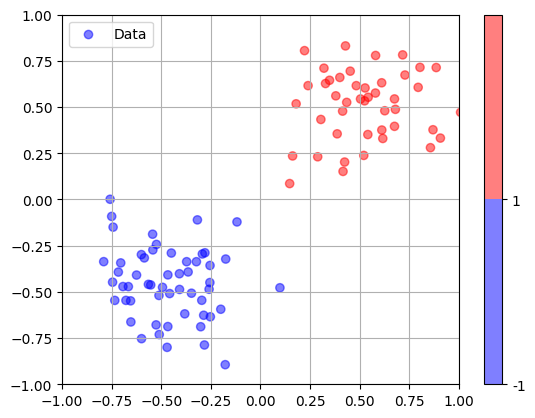

In [175]:
xTrain0, yTrain0 = generateBatchBipolar(N, sigma=0.2)
plotSvm(xTrain0, yTrain0)

### 3.2 使用Scikit Learn（SVC）的最大间隔分类器

使用SVC代替LinearSVC，因为SVC提供了支持向量。这些向量在下面的图中显示。

设置一个高的$C$参数以禁用软间隔。

In [176]:
## ----- 请在以下输入代码，实现 SVM 分类 ----- ##
model01 = svm.SVC(kernel='linear', C=1e10)
model01.fit(xTrain0, yTrain0)
print(f'Weights: {model01.coef_[0]}', f'Intercept: {model01.intercept_[0]}')

Weights: [4.67690632 3.65418788] Intercept: -0.0019327421353676696


Number of support vectors = 2


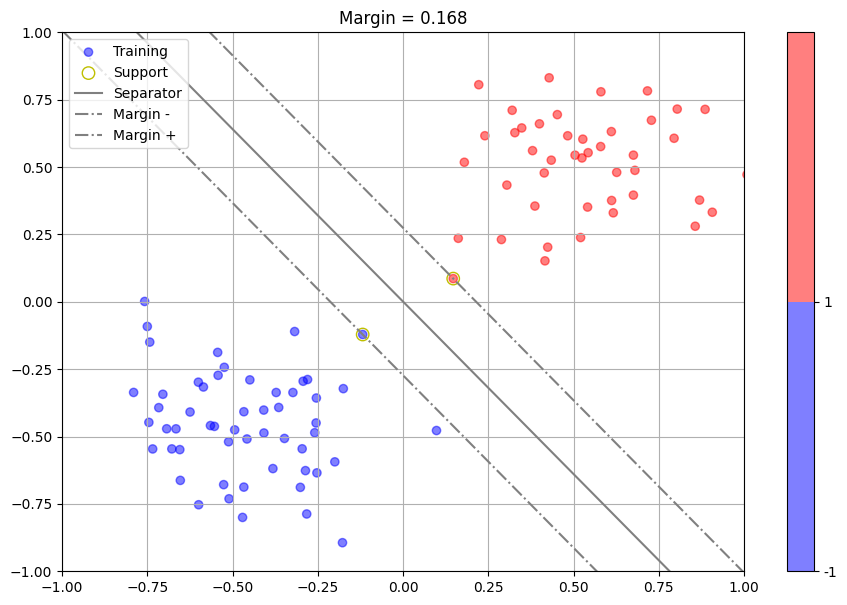

In [177]:
fig, ax = plt.subplots(1, figsize=(11, 7))
plotSvm(xTrain0, yTrain0, model01.support_vectors_, model01.coef_[0], model01.intercept_[0], 
        label='Training', ax=ax)

### 3.3 最大边界分类器与逻辑回归和线性判别分析（LDA）的比较

逻辑回归是基于线性回归的，它计算任意点 $x$ 到分离平面的平方误差，并使用sigmoid函数将其投影到概率空间，以便计算二元交叉熵。

线性判别分析（LDA）假设了一个高斯混合先验（在我们的情况下），并执行贝叶斯推断。



In [178]:
## ----- 请在以下输入代码，实现 逻辑回归 分类 ----- ##

model02 = linear_model.LogisticRegression()
model02.fit(xTrain0, yTrain0)
model02.coef_[0], model02.intercept_[0]

(array([2.84639098, 2.82159068]), np.float64(-0.2420122228257393))

In [179]:
## ----- 请在以下输入代码，实现 LDA 分类 ----- ##

model03 = discriminant_analysis.LinearDiscriminantAnalysis()
model03.fit(xTrain0, yTrain0)
model03.coef_[0], model03.intercept_[0]

(array([22.08799695, 23.0834398 ]), np.float64(-1.9529587579122811))

In [180]:
signedDist = np.matmul(model01.support_vectors_, model01.coef_[0])

我们观察到这三个模型的系数在幅度上非常不同，但总体上在二维平面上绘制了一条斜率为 $-\frac{\pi}{4}$ 的分隔线。


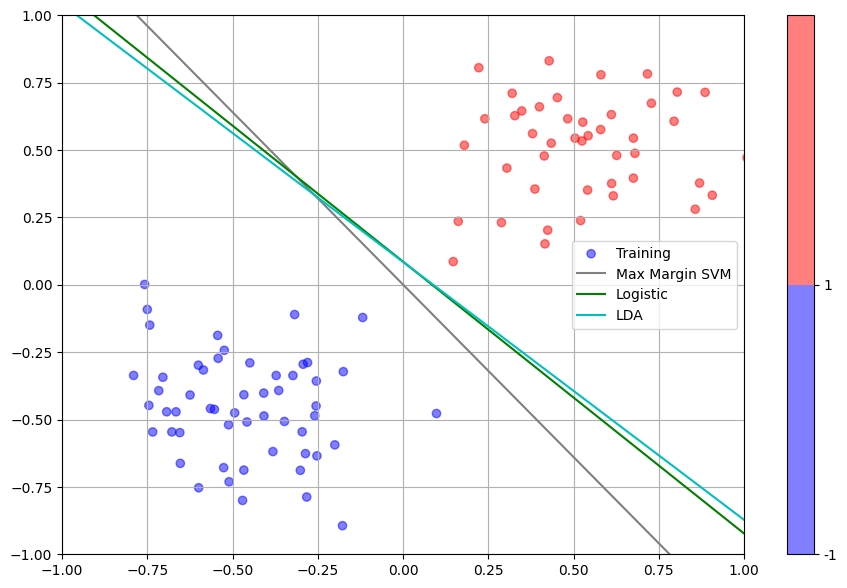

In [181]:
fig, ax = plt.subplots(1, figsize=(11, 7))
plotSvm(xTrain0, yTrain0, w=model01.coef_[0], intercept=model01.intercept_[0], 
        separatorLabel='Max Margin SVM', label='Training', ax=ax)
xx = np.array([-1., 1.])
plotLine(ax, xx, w=model02.coef_[0], x0=model02.intercept_[0], label='Logistic', color='g')
plotLine(ax, xx, w=model03.coef_[0], x0=model03.intercept_[0], label='LDA', color='c')
ax.legend();

## 4、 非线性可分类别的软间隔线性SVM

上述例子的兴趣不大，因为分离是微不足道的。

在非线性可分的情况下使用相同的SVM实现是不可能的，求解器会失败。

这里引入了软间隔：允许一些 $x_i$ 位于两个间隔条之间。


软间隔线性SVM在最大化 $M$ 时增加了一个正则化参数：

$$
\underset{w, b}{\max} \ M ( 1 - \xi_i)
$$
Subject to $\forall i = 1..n$：
- $y_i(x_i^T w + b) \ge M$
- $\Vert w \Vert = 1$
- $\xi_i \ge 0$

等价地：
$$
\min_{w, b} \frac 12 \Vert w \Vert^2 + C \sum_{i=1}^n \xi_i
$$
Subject to $\forall i = 1..n$：
- $\xi_i \ge 0$
- $y_i(x_i^T w + b) \ge 1 - \xi_i$


对应的拉格朗日原始问题是：

$$
\mathcal{L}_p(w, b, \alpha, \mu) = \frac{1}{2} \Vert w \Vert^2 - \sum_{i=0}^n \alpha_i (y_i(x_i^T w + b) - (1 - \xi_i)) - \sum_{i=0}^n \mu_i \xi_i 
$$

受限于 $\forall i \in 1..n$：
- $\alpha_i \ge 0$
- $\mu_i \ge 0$
- $\xi_i \ge 0$

这需要在 $w$、$b$ 和 $\xi_i$ 上进行最小化，使用相应的偏导数等于0，我们得到： 
$$
\begin{align}
\sum_{i=0}^n \alpha_i y_i x_i &= w \\\
\sum_{i=0}^n \alpha_i y_i &= 0 \\\
\alpha_i &= C - \mu_i
\end{align}
$$

从 $\mathcal{L}_p$，我们得到（沃尔夫）对偶问题： 
$$
\begin{align}
\mathcal{L}_d (\alpha)
&= \sum_{i=0}^n \alpha_i - \frac{1}{2} \sum_{i=0}^n \sum_{k=0}^n \alpha_i \alpha_k y_i y_k x_i^T x_k \\\
&= \sum_{i=0}^n \alpha_i - \frac{1}{2} \sum_{i=0}^n \sum_{k=0}^n \langle \alpha_i y_i x_i, \alpha_k y_k x_k \rangle \\
\end{align}
$$

受限于 $\forall i \in 1..n$：
- $0 \le \alpha_i \le C$
- $\sum_{i=0}^n \alpha_i y_i = 0$

这个问题与最大间隔分隔器的问题非常相似，但是对 $\alpha$ 有一个额外的约束。

它是一个凹问题，使用求解器进行最大化。

需要额外的条件来获得强对偶性（KKT），$\forall i \in 1..n$：
- $\alpha_i (y_i(x_i^T w + b) - (1 - \xi_i)) = 0$
- $\mu_i \xi_i = 0$
- $y_i(x_i^T w + b) - (1 - \xi_i) \ge 0$


### 4.1 数据模型

让我们重新使用由两个高斯分布组成的相同模型，但增加方差，以便将正点和负点混合在一起。


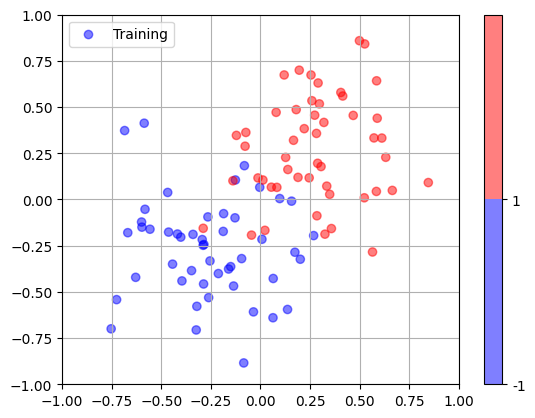

In [182]:
xTrain1, yTrain1 = generateBatchBipolar(N, mu=0.3, sigma=0.3)
plotSvm(xTrain1, yTrain1, label='Training')

### 4.2 使用 Scikit Learn 实现线性 SVM

In [183]:
## ----- 请在以下输入代码，实现 软间隔SVM 分类 ----- ##
model11 = svm.SVC(kernel='linear', C=1.0)  # C越小，软间隔容忍度越高
model11.fit(xTrain1, yTrain1)
model11.coef_[0], model11.intercept_[0]

(array([2.63995785, 2.39868871]), np.float64(0.09521738940384239))

Number of support vectors = 36


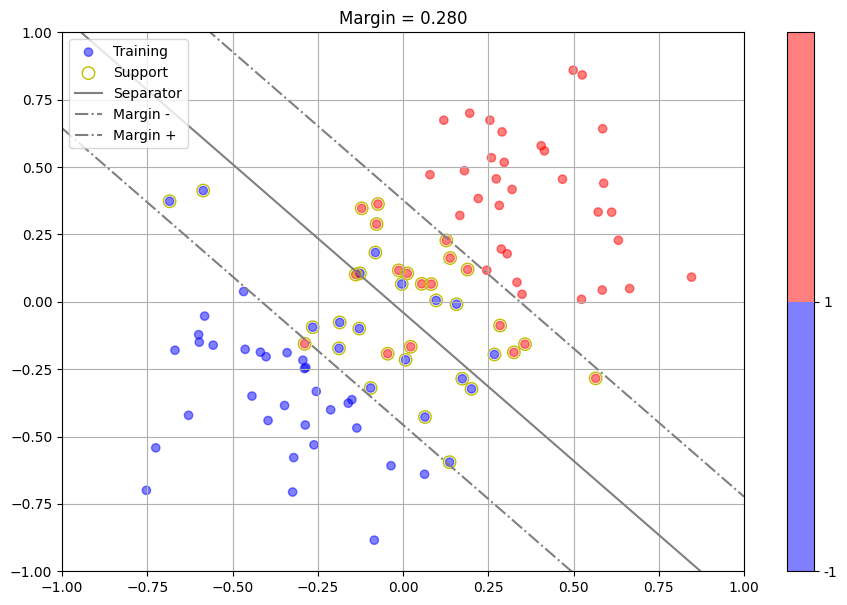

In [184]:
fig, ax = plt.subplots(1, figsize=(11, 7))
plotSvm(xTrain1, yTrain1, model11.support_vectors_, model11.coef_[0], model11.intercept_[0], 
        label='Training', ax=ax)

使用软间隔时，支持向量是所有位于边界上或Margin内部的向量。

### 4.3 软间隔分类器与逻辑回归和线性判别分析（LDA）的比较

In [185]:
## ----- 请在以下输入代码，实现 逻辑回归 分类 ----- ##
model12 = linear_model.LogisticRegression()
model12.fit(xTrain1, yTrain1)
model12.coef_[0], model12.intercept_[0]

(array([2.97653902, 2.81433967]), np.float64(0.01770348826068626))

In [186]:
## ----- 请在以下输入代码，实现 LDA 分类 ----- ##
model13 = discriminant_analysis.LinearDiscriminantAnalysis()
model13.fit(xTrain1, yTrain1)
model13.coef_[0], model13.intercept_[0]

(array([7.4241293 , 6.79289377]), np.float64(0.0))

正如下面所示，这三个模型的分隔超平面非常相似，都是负斜率。

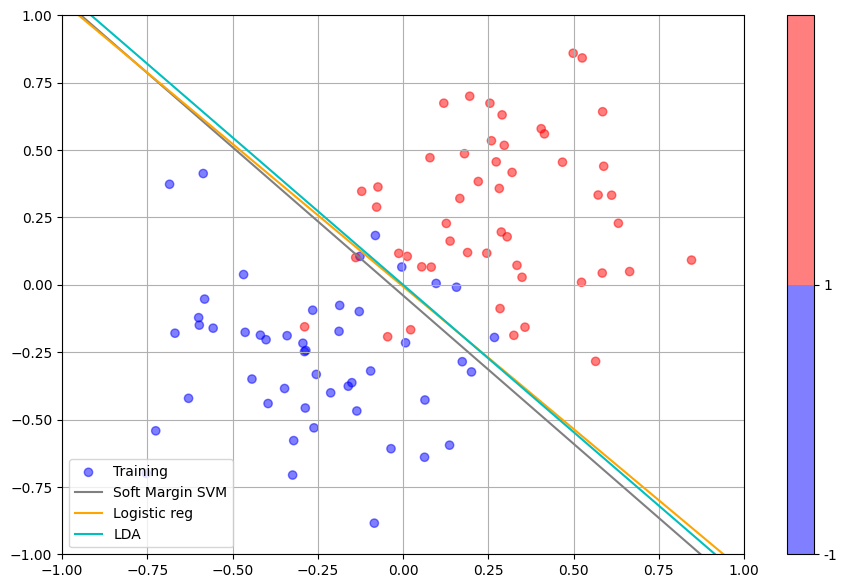

In [187]:
fig, ax = plt.subplots(1, figsize=(11, 7))
plotSvm(xTrain1, yTrain1, w=model11.coef_[0], intercept=model11.intercept_[0], label='Training',
        separatorLabel='Soft Margin SVM', ax=ax)
xx = np.array([-1., 1.])
plotLine(ax, xx, w=model12.coef_[0], x0=model12.intercept_[0], label='Logistic reg', color='orange')
plotLine(ax, xx, w=model13.coef_[0], x0=model13.intercept_[0], label='LDA', color='c')
ax.legend();

### 4.4 使用测试数据集验证



In [188]:
xTest1, yTest1 = generateBatchBipolar(2*N, mu=0.3, sigma=0.3)

#### 二元分类性能的辅助工具函数


In [189]:
def plotHeatMap(X, classes, title=None, fmt='.2g', ax=None, xlabel=None, ylabel=None):
    """ Fix heatmap plot from Seaborn with pyplot 3.1.0, 3.1.1
        https://stackoverflow.com/questions/56942670/matplotlib-seaborn-first-and-last-row-cut-in-half-of-heatmap-plot
    """
    ax = sns.heatmap(X, xticklabels=classes, yticklabels=classes, annot=True, \
                     fmt=fmt, cmap=plt.cm.Blues, ax=ax) #notation: "annot" not "annote"
    bottom, top = ax.get_ylim()
    ax.set_ylim(bottom + 0.5, top - 0.5)
    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
        
def plotConfusionMatrix(yTrue, yEst, classes, title=None, fmt='.2g', ax=None):
    plotHeatMap(metrics.confusion_matrix(yTrue, yEst), classes, title, fmt, ax, xlabel='Estimations', \
                ylabel='True values');

#### 混淆矩阵


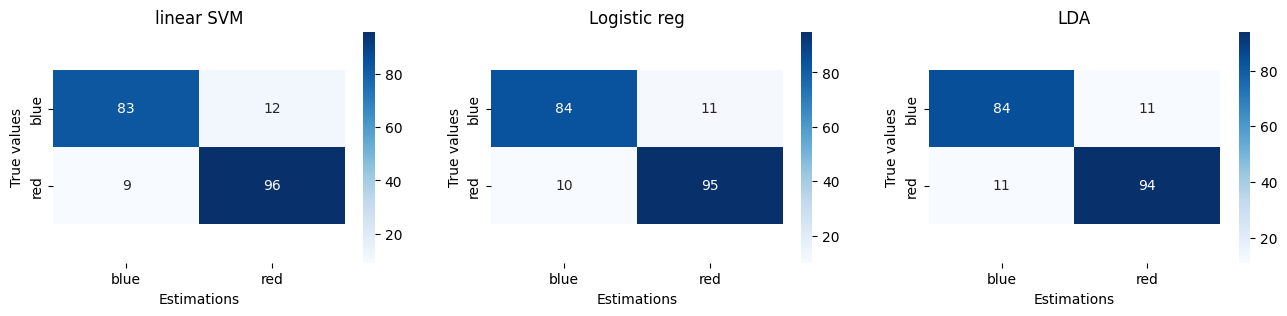

In [190]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3))
for model, ax, title in zip([model11, model12, model13], axes, ['linear SVM', 'Logistic reg', 'LDA']):
    yEst = model.predict(xTest1)
    plotConfusionMatrix(yTest1, yEst, colors, title, ax=ax)

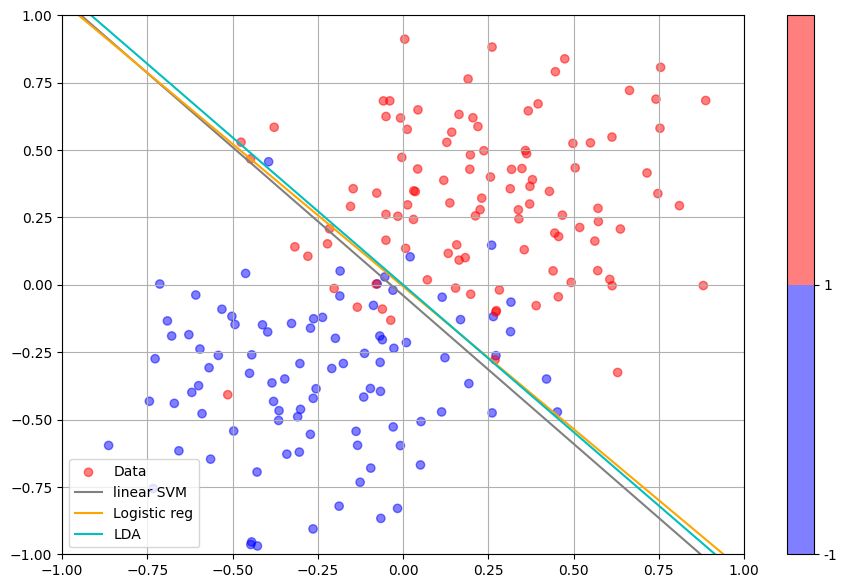

In [191]:
fig, ax = plt.subplots(1, figsize=(11, 7))
plotSvm(xTest1, yTest1, w=model11.coef_[0], intercept=model11.intercept_[0], separatorLabel='linear SVM', ax=ax)
xx = np.array([-1., 1.])
plotLine(ax, xx, w=model12.coef_[0], x0=model12.intercept_[0], label='Logistic reg', color='orange')
plotLine(ax, xx, w=model13.coef_[0], x0=model13.intercept_[0], label='LDA', color='c')
ax.legend();

## 5. 对于线性不可分的数据采用的 "核技巧" (Kernel trick)

让我们使用一个非常著名的数据集来展示逻辑回归和LDA的主要局限性：XOR（异或）。


In [192]:
def generateBatchXor(n, mu=0.5, sigma=0.5):
    """ Four gaussian clouds in a Xor fashion """
    X = np.random.normal(mu, sigma, (n, 2))
    yB0 = np.random.uniform(0, 1, n) > 0.5
    yB1 = np.random.uniform(0, 1, n) > 0.5
    # y is in {-1, 1}
    y0 = 2. * yB0 - 1
    y1 = 2. * yB1 - 1
    X[:,0] *= y0
    X[:,1] *= y1
    X -= X.mean(axis=0)
    return X, y0*y1

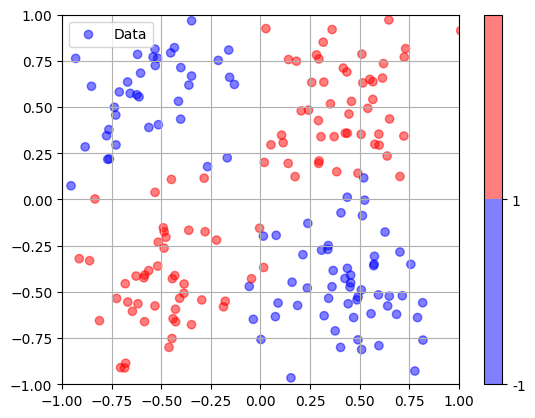

In [193]:
xTrain3, yTrain3 = generateBatchXor(2*N, sigma=0.25)
plotSvm(xTrain3, yTrain3)
xTest3, yTest3 = generateBatchXor(2*N, sigma=0.25)

### 逻辑回归和LDA在XOR问题上的应用


In [194]:
## ----- 请在以下输入代码，实现 逻辑回归 分类 ----- ##

model32 = linear_model.LogisticRegression()
model32.fit(xTrain3, yTrain3)
model32.coef_[0], model32.intercept_[0]

(array([-0.33274299,  0.3931961 ]), np.float64(0.08155984069773442))

In [195]:
## ----- 请在以下输入代码，实现 LDA 分类 ----- ##

model33 = discriminant_analysis.LinearDiscriminantAnalysis()
model33.fit(xTrain3, yTrain3)
model33.coef_[0], model33.intercept_[0]

(array([-0.35517921,  0.4189204 ]), np.float64(0.0817916654969123))

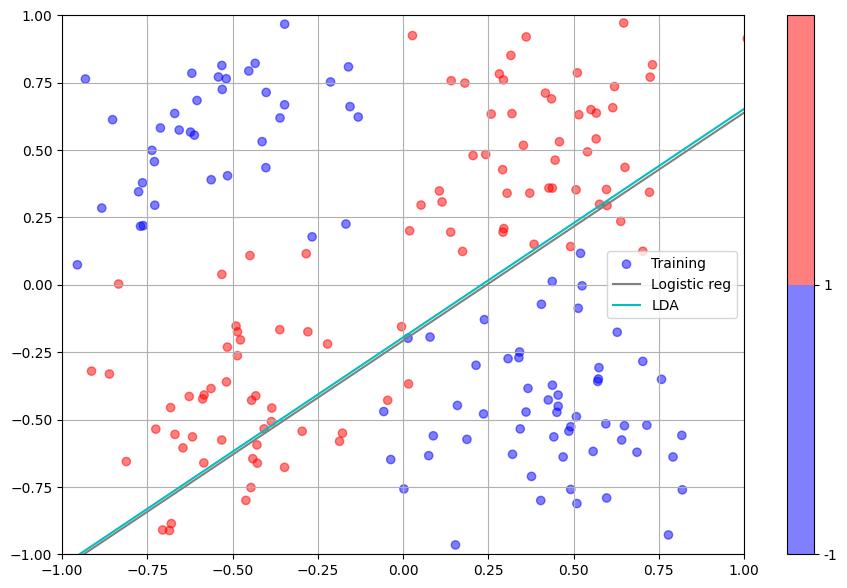

In [196]:
fig, ax = plt.subplots(1, figsize=(11, 7))
plotSvm(xTrain3, yTrain3, w=model32.coef_[0], intercept=model32.intercept_[0], label='Training',
        separatorLabel='Logistic reg', ax=ax)
xx = np.array([-1., 1.])
plotLine(ax, xx, w=model33.coef_[0], x0=model33.intercept_[0], label='LDA', color='c')
ax.legend();

## 6、 引入核技巧

在使用像回归这样的线性分隔器时，处理非线性函数的传统方法是使用初始特征的幂和乘积来扩展特征空间。在多类问题的情况下，这也是必要的。

这种技巧有其局限性。例如，XOR问题就没有得到妥善处理。

SVM采用了一种称为“核技巧”的新方法。

让我们使用函数 \( h(x) \) 对 \( x \) 进行变换。

拉格朗日（沃尔夫）对偶问题变为：
$$
\begin{align}
\mathcal{L}_d (\alpha)
&= \sum_{i=0}^n \alpha_i - \frac{1}{2} \sum_{i=0}^n \sum_{k=0}^n \alpha_i \alpha_k y_i y_k h(x_i)^T h(x_k) \\
&= \sum_{i=0}^n \alpha_i - \frac{1}{2} \sum_{i=0}^n \sum_{k=0}^n \alpha_i \alpha_k \langle y_i h(x_i), y_k h(x_k) \rangle \\
\end{align}
$$

受限于 $\forall i \in 1..n$：
- $0 \le \alpha_i \le C$
- $\sum_{i=0}^n \alpha_i y_i = 0$

由于 $ w = \sum_{i=0}^n \alpha_i y_i h(x_i)$，预测函数现在是：
$$
f(x) = sign(w^T h(x) + b) = sign \left(\sum_{i=0}^n \alpha_i y_i \langle h(x_i), h(x) \rangle \right)
$$

这个预测需要计算 $\alpha_i > 0$，即支持向量。

拟合和预测都基于内积 $K(x, x') = \langle h(x), h(x') \rangle$，也称为核函数。这个函数应该是对称的，半正定的。

流行的核是高斯径向基函数（RBF）：$K(x, x') = exp(- \gamma \Vert x - x' \Vert^2 )$。


In [197]:
## ----- 请在以下输入代码，实现 Kernel-SVM 分类 ----- ##

model31 = svm.SVC(kernel='rbf', C=1.0, gamma='scale')  
model31.fit(xTrain3, yTrain3)

SVC()

Number of support vectors = 52


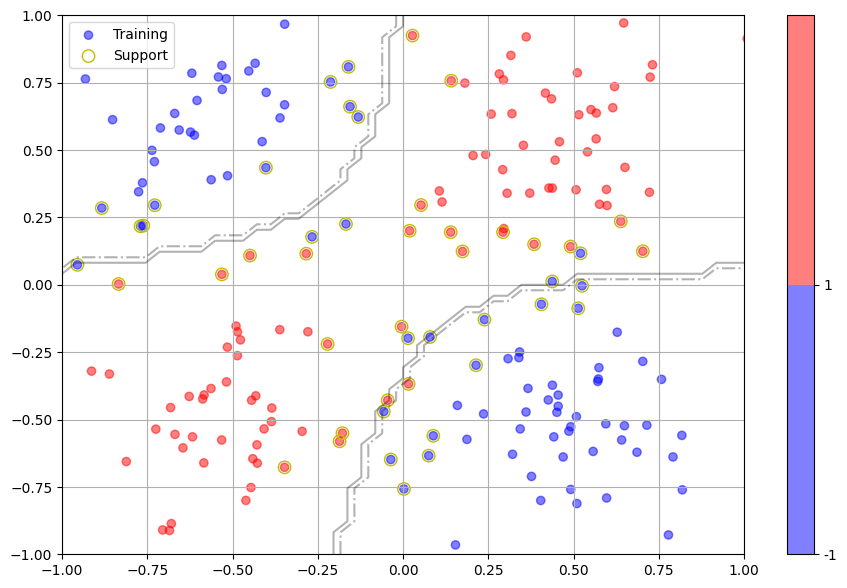

In [198]:
fig, ax = plt.subplots(1, figsize=(11, 7))
plotSvm(xTrain3, yTrain3, support=model31.support_vectors_, label='Training', ax=ax)

# Estimate and plot decision boundary
xx = np.linspace(-1, 1, 50)
X0, X1 = np.meshgrid(xx, xx)
xy = np.vstack([X0.ravel(), X1.ravel()]).T

Y31 = model31.predict(xy).reshape(X0.shape)
ax.contour(X0, X1, Y31, colors='k', levels=[-1, 0], alpha=0.3, linestyles=['-.', '-']);

### 6.1 SVM with RBF 在 XOR 数据中的表现

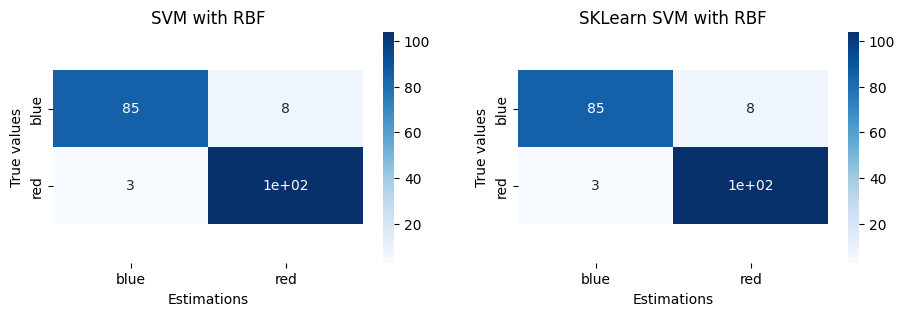

In [199]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for model, ax, title in zip([model31, model31], axes, ["SVM with RBF", "SKLearn SVM with RBF"]):
    yEst3 = model.predict(xTest3)
    plotConfusionMatrix(yTest3, yEst3, colors, title, ax=ax)

## 7. 结论

我们已经展示了SVM分类器在处理非线性可分问题方面的强大能力。从20世纪90年代末开始，SVM是许多问题的领先机器学习算法家族。然而，自2010年以来，随着深度学习在某些类别的问题上展现出更好的性能，这种情况已经发生了一些变化。不过，SVM在许多情境下仍然更为强大。例如，SVM所需的训练数据量比深度学习所需的少。


## 8. 独立完成作业

对糖尿病（diabete）数据集，建立支持向量机分类器判别其样本的类别，评估所设计的分类模型的泛化性能。再与其它分类方法（例如k近邻分类方法或决策树分类方法）进行性能对比，给出哪种方法的泛化性能更好的结论。

注：皮马印第安人糖尿病（Pima Indians Diabetes）数据集包含2个类型的样本，分别有268个糖尿病样本和500个非糖尿病样本。数据文件的9列对应8个属性和1个类标（有糖尿病是1，无是0）。

- 简单写出你的求解设计（例如：如何处理原始数据、每种分类方法的特点、如何进行泛化性能的评估，如何找出更好性能的方法，等等）；
- 编程实现上述设计，全部代码添加在此notebook内（添加必要的注释说明）；
- 获得的结果，即分类模型、泛化性能及性能对比情况。